In [1]:
# CNN - CIFAR-10 Image Classification
# https://www.researchgate.net/publication/323026933/figure/fig2/AS:591960742043648@1518145847527/Some-labeled-and-unlabeled-images-of-CIFAR-10-after-Stage-1.png

# https://www.theclickreader.com/wp-content/uploads/2020/08/color-channels-RGB.jpg

# https://media.geeksforgeeks.org/wp-content/uploads/20230329095332/RGB-arrays-combined-to-make-image.jpg

# https://miro.medium.com/v2/resize:fit:1296/1*8zHs6CWVv_ljVQEEZ71fNQ.png

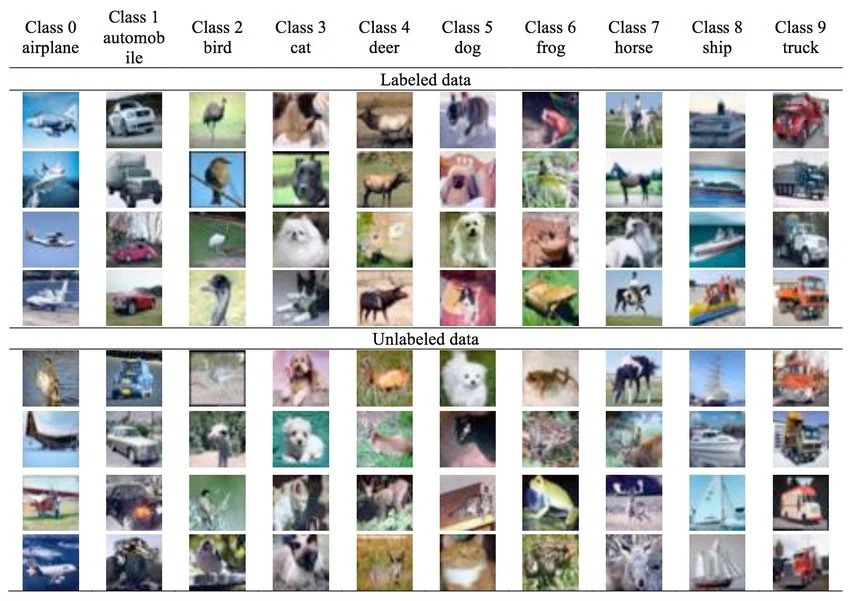

![alt text](RGB-arrays-combined-to-make-image.jpg)

![alt text](1_8zHs6CWVv_ljVQEEZ71fNQ.png)

![alt text](color-channels-RGB.jpg)

In [2]:
# Import necessary libraries
import tensorflow as tf

# Let me load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Check the shapes of the data
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 147s 1us/step


c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3), Testing labels shape: (10000, 1)


In [3]:
# CIFAR-10 has 10 classes
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Label names:", label_names)

Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


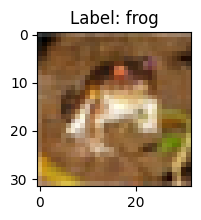

In [4]:
# Plot the image - 0th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[0])
plt.title(f"Label: {label_names[y_train[0][0]]}")
plt.show()

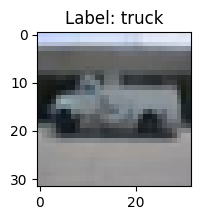

In [5]:
# Plot the image - 110th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[110])
plt.title(f"Label: {label_names[y_train[110][0]]}")
plt.show()

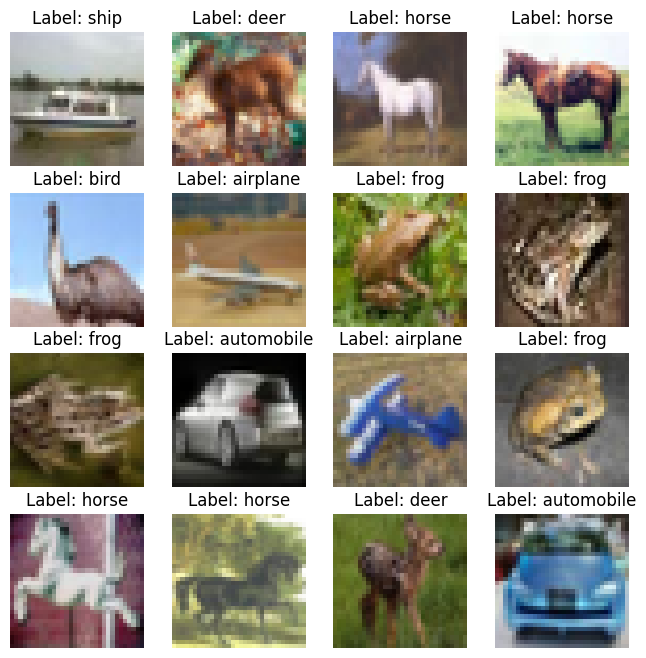

In [6]:
# Lets plot a grid of 4x4 images from the training set along with their labels in the title - randomly select 16 images from the training set
import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx][0]]}")
    axes[row, col].axis("off")

plt.show()

In [7]:
y_train.shape

(50000, 1)

In [8]:
# Also note over here that the targets are 2D array N x 1 instead of N.
# Therefore, we flatten them.
y_train, y_test = y_train.flatten(), y_test.flatten()
print(y_train.shape)
print(y_test.shape)

(50000,)
(10000,)


In [9]:
# number of classes
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [10]:
# Now lets normalize the pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

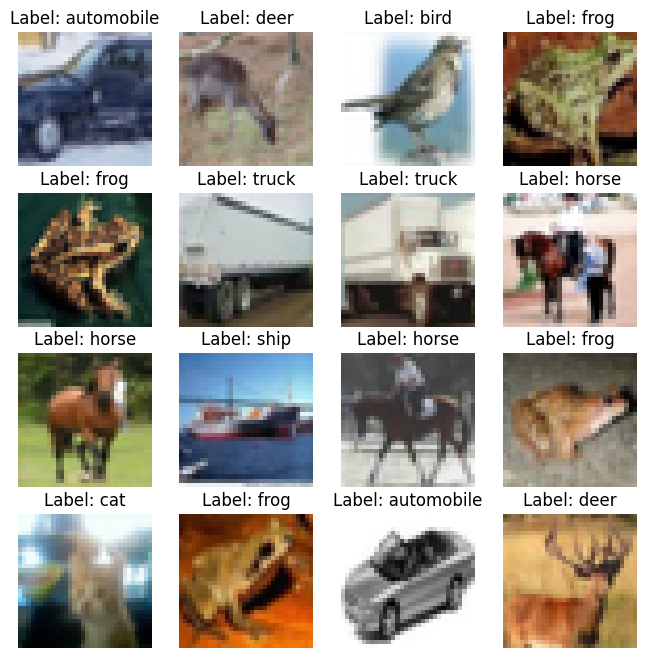

In [11]:
# Lets plot a grid of 4x4 images from the training set along with their labels in the title - randomly select 16 images from the training set
import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx]]}")
    axes[row, col].axis("off")
plt.show()

In [12]:
# Now let's create a ANN model for image classification on CIFAR-10 dataset. We will look into the performance of ANN on this dataset and then confirm our hypothesis that ANN will not perform well on this dataset and then we will move on to CNNs which are more suitable for image data.

# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# model = Sequential()
# model.add(Input(shape=(32, 32, 3)))
# model.add(Flatten())

# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(10, activation='softmax'))

In [13]:
# Now we are ready to build the model. We will use a simple CNN architecture with 3 convolutional layers followed by a fully connected layer and an output layer.

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [14]:
32*32*3

3072

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,594 (2.52 MB)

 Trainable params: 659,594 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
# Train the model
r = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=64)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 37ms/step - accuracy: 0.2741 - loss: 1.8973 - val_accuracy: 0.4364 - val_loss: 1.4777
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.4734 - loss: 1.4464 - val_accuracy: 0.5730 - val_loss: 1.1764
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.5665 - loss: 1.2383 - val_accuracy: 0.6287 - val_loss: 1.0573
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.6162 - loss: 1.1190 - val_accuracy: 0.6532 - val_loss: 0.9816
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.6520 - loss: 1.0296 - val_accuracy: 0.6566 - val_loss: 1.0261
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.6725 - loss: 0.9752 - val_accuracy: 0.6788 - val_loss: 0.9212
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.6958 - loss: 0.9119 - val_accuracy: 0.6971 - val_loss: 0.9314
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.7163 - loss: 0.8562 - 

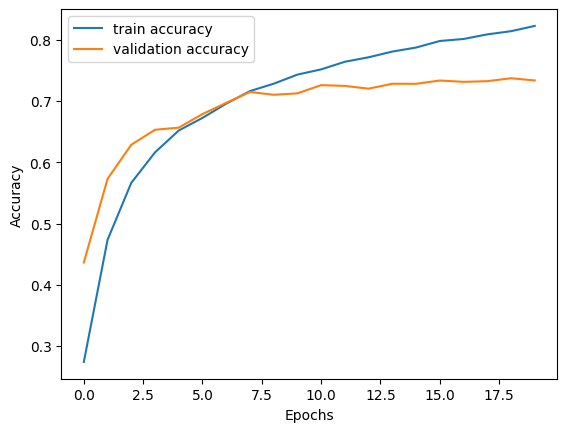

In [18]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

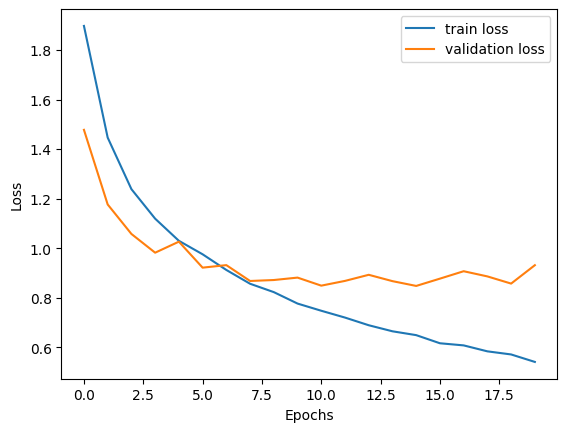

In [19]:
# Plot the loss and validation loss per epoch
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
import numpy as np
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([5, 8, 1, ..., 5, 1, 7], shape=(10000,))

In [21]:
y_pred.shape

(10000,)

In [22]:
y_test.shape

(10000,)

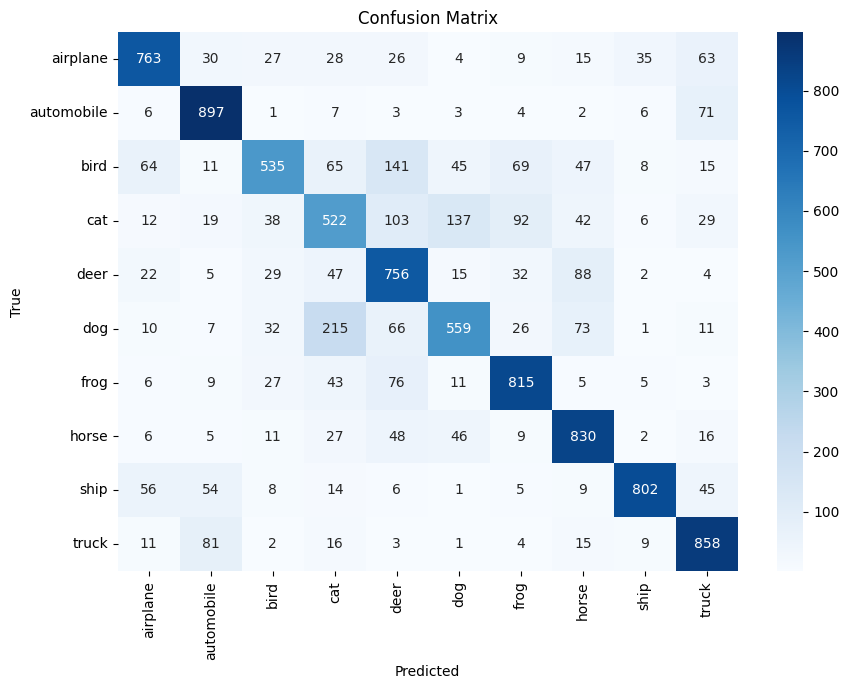

In [23]:
# Lets look at the confusion matrix with True labels on x-axis and Predicted labels on y-axis
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Find the indices where predictions are incorrect
misclassified_indices = np.where(y_test.flatten() != y_pred)[0]
misclassified_indices

array([   0,    2,   12, ..., 9985, 9986, 9989], shape=(2663,))

In [25]:
# Print the total number of misclassified images
print(f'Total misclassified images: {len(misclassified_indices)}')

Total misclassified images: 2663


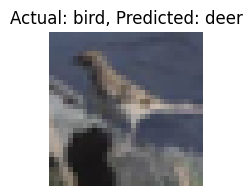

In [26]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

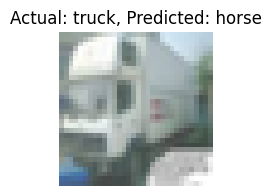

In [27]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

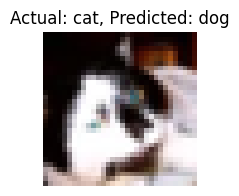

In [28]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

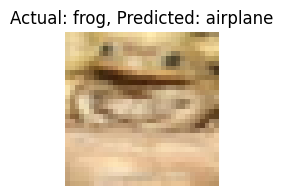

In [29]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

# Happy Learning